In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset (1).csv to dataset (1).csv


In [2]:
!mv "dataset (1).csv" dataset.csv
!ls -lh dataset.csv
!pip install -q xgboost tabulate
!python ablation_study.py

-rw-r--r-- 1 root root 20M Sep  7 23:59 dataset.csv
python3: can't open file '/content/ablation_study.py': [Errno 2] No such file or directory


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, f1_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("dataset.csv")

print("Raw shape:", df.shape)
print("\nColumns:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])


# ====================================================================
# 2. DATA CLEANING
# ====================================================================
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

n0 = len(df)

# 2.1 Drop the exported row-index column
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])

# 2.2 Drop rows with missing values (a handful of tracks have null names)
df = df.dropna(subset=["track_name", "artists", "album_name"])
print(f"After dropping nulls:            {len(df):>6}  (-{n0 - len(df)})")

# 2.3 Duplicate tracks.
#     The dataset is built as 114 genres x 1000 tracks, so the SAME track_id
#     appears under several genres. Keeping them inflates the row count and
#     leaks near-identical rows across the train/test split.
n1 = len(df)
df = df.drop_duplicates(subset=["track_id"], keep="first").reset_index(drop=True)
print(f"After dropping duplicate tracks: {len(df):>6}  (-{n1 - len(df)})")

# 2.4 Physically impossible values (visible as the tempo=0 / loudness=-50 band
#     in the loudness-vs-tempo scatter plot).
n2 = len(df)
df = df[(df["tempo"] > 0) &
        (df["duration_ms"] > 30_000) &          # under 30s = not a real track
        (df["duration_ms"] < 900_000) &         # over 15 min = outlier
        (df["loudness"] > -40) &
        (df["time_signature"] > 0)].reset_index(drop=True)
print(f"After removing invalid rows:     {len(df):>6}  (-{n2 - len(df)})")

# 2.5 Range sanity check on the [0,1] audio features
for col in ["danceability", "energy", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence"]:
    df = df[df[col].between(0, 1)]
df = df.reset_index(drop=True)
print(f"Final clean shape:               {len(df):>6}")

Raw shape: (114000, 21)

Columns:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Missing values:
 artists       1
album_name    1
track_name    1
dtype: int64

DATA CLEANING
After dropping nulls:            113999  (-1)
After dropping duplicate tracks:  89740  (-24259)
After removing invalid rows:      89405  (-335)
Final clean shape:                89405


In [6]:
# ====================================================================
# 3. TARGET DEFINITION
# ====================================================================
POP_THRESHOLD = 60
df["popular"] = (df["popularity"] > POP_THRESHOLD).astype(int)

print("\nClass balance:")
print(df["popular"].value_counts())
print(df["popular"].value_counts(normalize=True).round(4))
print(f"\n>>> Majority-class baseline accuracy = "
      f"{(1 - df['popular'].mean()):.4f}")
print(">>> Any model must beat THIS, not 50%.")


Class balance:
popular
0    80576
1     8829
Name: count, dtype: int64
popular
0    0.9012
1    0.0988
Name: proportion, dtype: float64

>>> Majority-class baseline accuracy = 0.9012
>>> Any model must beat THIS, not 50%.



EDA
                    count        mean        std        min         25%  \
danceability      89405.0       0.563      0.175      0.051       0.451   
energy            89405.0       0.636      0.255      0.000       0.459   
loudness          89405.0      -8.458      5.143    -39.869     -10.289   
speechiness       89405.0       0.088      0.113      0.022       0.036   
acousticness      89405.0       0.328      0.338      0.000       0.017   
instrumentalness  89405.0       0.172      0.323      0.000       0.000   
liveness          89405.0       0.217      0.194      0.009       0.098   
valence           89405.0       0.471      0.262      0.000       0.251   
tempo             89405.0     122.287     29.707     30.200      99.557   
duration_ms       89405.0  227099.840  88349.157  30080.000  173133.000   
popularity        89405.0      33.209     20.594      0.000      19.000   

                         50%         75%         max  
danceability           0.577       0.69

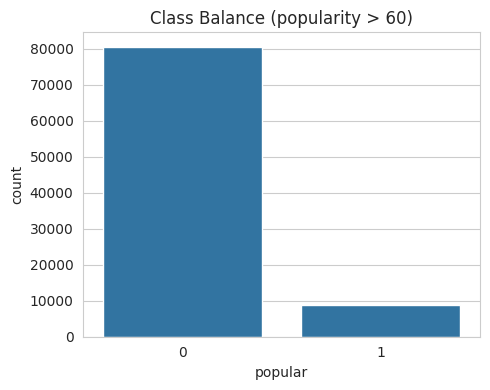

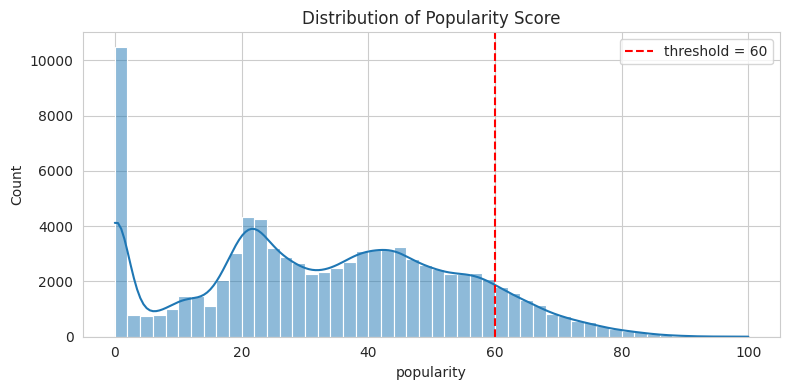

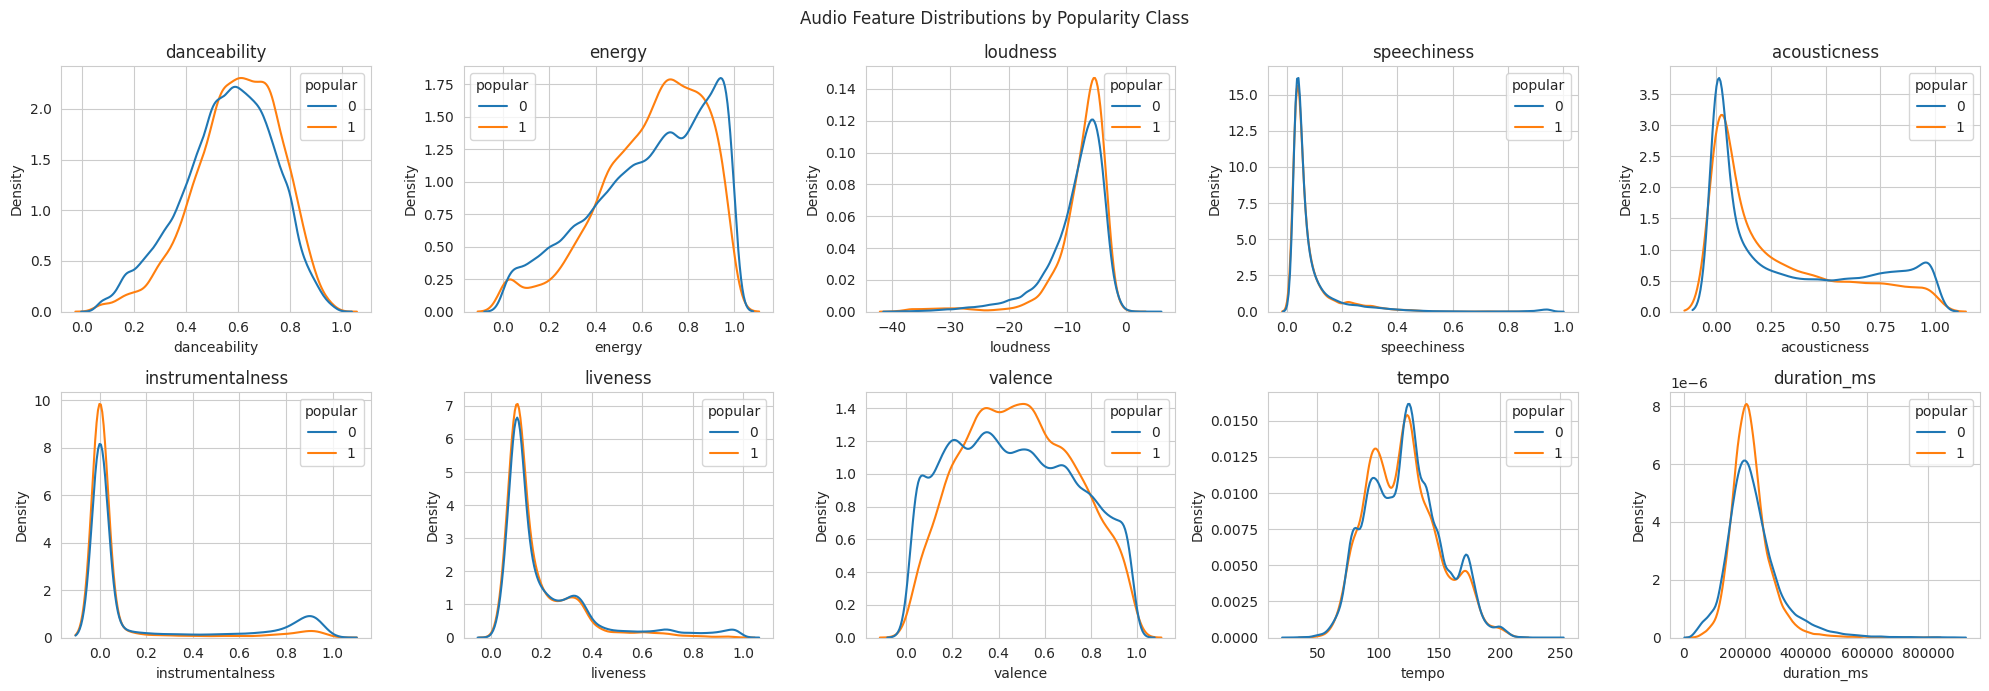

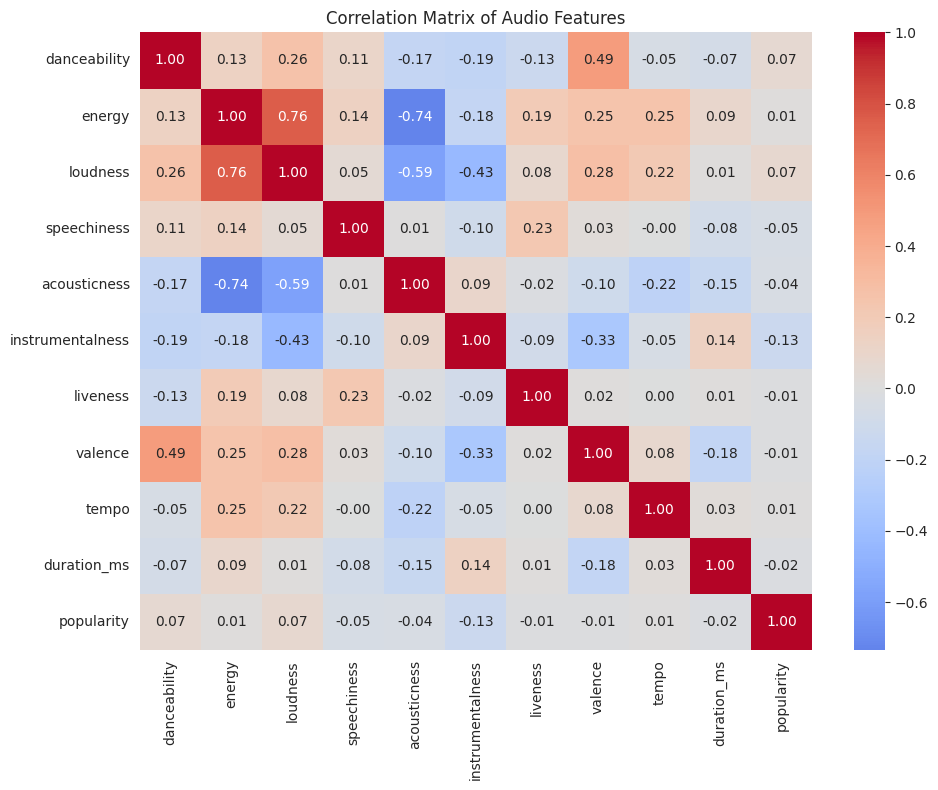

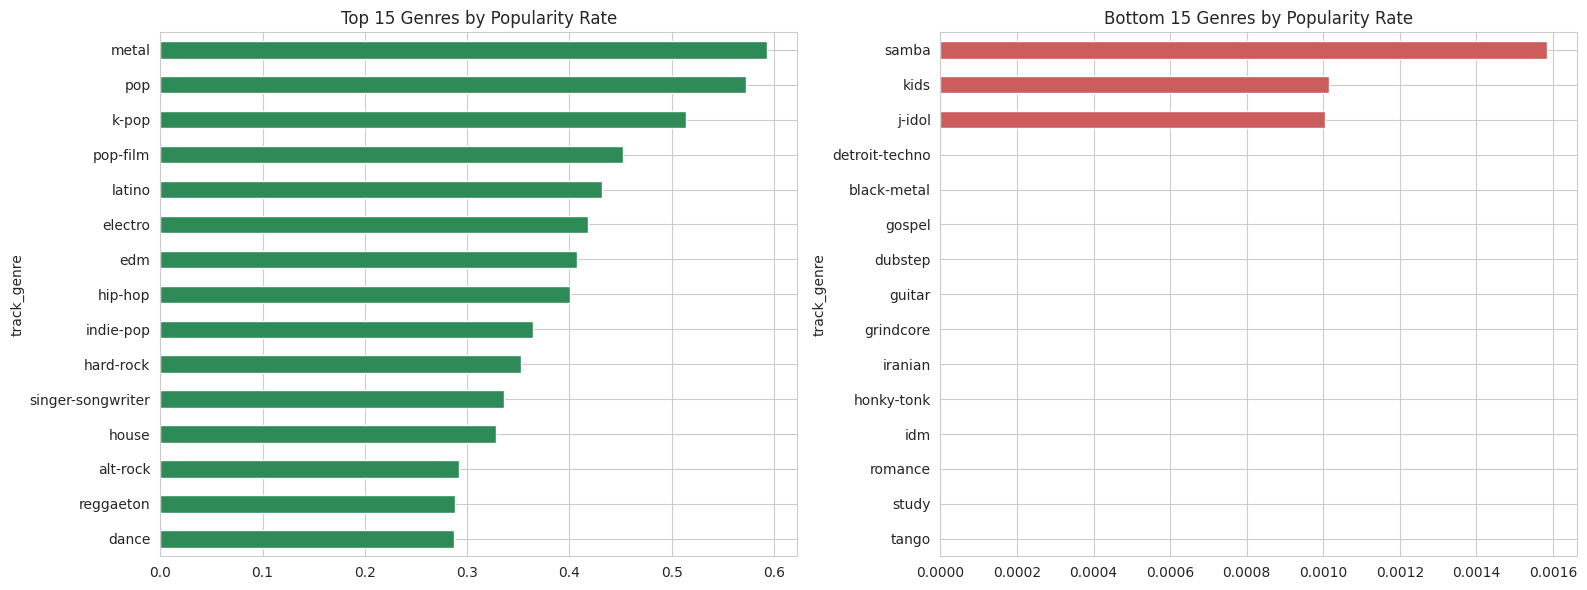


Genre popularity rate ranges from 0.000 to 0.593 -- genre carries far more signal than any single audio feature (max |corr| = 0.128).

Popularity rate by explicit flag:
            mean  count
explicit               
False     0.0925  81707
True      0.1652   7698


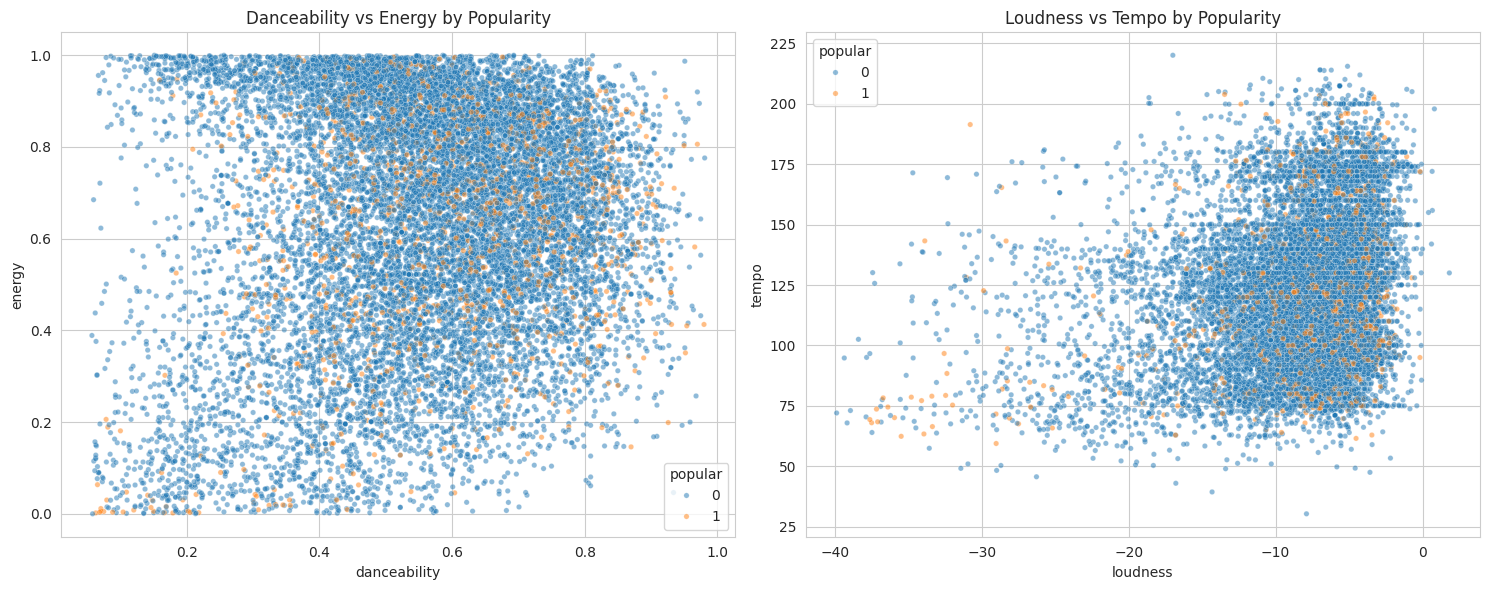

In [7]:
# ====================================================================
# 4. EXPLORATORY DATA ANALYSIS
# ====================================================================
print("\n" + "=" * 60)
print("EDA")
print("=" * 60)

AUDIO = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]

print(df[AUDIO + ["popularity"]].describe().T.round(3))

# 4.1 Class balance
plt.figure(figsize=(5, 4))
sns.countplot(x="popular", data=df)
plt.title(f"Class Balance (popularity > {POP_THRESHOLD})")
plt.tight_layout(); plt.show()

# 4.2 Distribution of the raw popularity score
plt.figure(figsize=(8, 4))
sns.histplot(df["popularity"], bins=50, kde=True)
plt.axvline(POP_THRESHOLD, color="red", ls="--", label=f"threshold = {POP_THRESHOLD}")
plt.title("Distribution of Popularity Score")
plt.legend(); plt.tight_layout(); plt.show()

# 4.3 Feature distributions split by class
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), AUDIO):
    sns.kdeplot(data=df, x=col, hue="popular", common_norm=False, ax=ax)
    ax.set_title(col)
plt.suptitle("Audio Feature Distributions by Popularity Class")
plt.tight_layout(); plt.show()

# 4.4 Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[AUDIO + ["popularity"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Audio Features")
plt.tight_layout(); plt.show()

# 4.5 Genre effect  <-- the strongest signal in the dataset
genre_pop = (df.groupby("track_genre")["popular"].mean()
               .sort_values(ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
genre_pop.head(15).plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Top 15 Genres by Popularity Rate"); axes[0].invert_yaxis()
genre_pop.tail(15).plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("Bottom 15 Genres by Popularity Rate"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

print(f"\nGenre popularity rate ranges from {genre_pop.min():.3f} to "
      f"{genre_pop.max():.3f} -- genre carries far more signal than any single "
      f"audio feature (max |corr| = "
      f"{df[AUDIO].corrwith(df['popularity']).abs().max():.3f}).")

# 4.6 Explicit flag
print("\nPopularity rate by explicit flag:")
print(df.groupby("explicit")["popular"].agg(["mean", "count"]).round(4))

# 4.7 Scatter plots from the original report
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df.sample(15000, random_state=RANDOM_STATE),
                x="danceability", y="energy", hue="popular",
                alpha=0.5, s=15, ax=axes[0])
axes[0].set_title("Danceability vs Energy by Popularity")
sns.scatterplot(data=df.sample(15000, random_state=RANDOM_STATE),
                x="loudness", y="tempo", hue="popular",
                alpha=0.5, s=15, ax=axes[1])
axes[1].set_title("Loudness vs Tempo by Popularity")
plt.tight_layout(); plt.show()


In [8]:
# ====================================================================
# 5. FEATURE ENGINEERING
# ====================================================================
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

fe = df.copy()

# 5.1 Duration in minutes (more interpretable than milliseconds)
fe["duration_min"] = fe["duration_ms"] / 60_000

# 5.2 Log transforms for the heavily right-skewed features
for col in ["speechiness", "liveness", "instrumentalness"]:
    fe[f"log_{col}"] = np.log1p(fe[col])

# 5.3 Composite / interaction features with a musical justification
fe["mood"]        = fe["valence"] * fe["energy"]            # happy AND driving
fe["intensity"]   = fe["energy"] * fe["loudness"].abs()     # perceived power
fe["dance_energy"] = fe["danceability"] * fe["energy"]
fe["acoustic_ratio"] = fe["acousticness"] / (fe["energy"] + 1e-6)
fe["is_instrumental"] = (fe["instrumentalness"] > 0.5).astype(int)
fe["is_live"] = (fe["liveness"] > 0.8).astype(int)

# 5.4 Binned tempo (radio-friendly range)
fe["tempo_band"] = pd.cut(fe["tempo"], bins=[0, 90, 120, 150, 300],
                          labels=[0, 1, 2, 3]).astype(int)

# 5.5 Categorical variables the original analysis discarded
fe["explicit"] = fe["explicit"].astype(int)
fe["mode"] = fe["mode"].astype(int)
key_dummies = pd.get_dummies(fe["key"], prefix="key").astype(int)
fe = pd.concat([fe, key_dummies], axis=1)

# 5.6 Artist track count (a proxy for catalogue size / presence)
fe["artist_track_count"] = fe.groupby("artists")["artists"].transform("count")

ENGINEERED = (["duration_min", "log_speechiness", "log_liveness",
               "log_instrumentalness", "mood", "intensity", "dance_energy",
               "acoustic_ratio", "is_instrumental", "is_live", "tempo_band",
               "explicit", "mode", "time_signature", "artist_track_count"]
              + list(key_dummies.columns))

BASE = ["danceability", "energy", "loudness", "speechiness", "acousticness",
        "instrumentalness", "liveness", "valence", "tempo"]

print(f"Base features:       {len(BASE)}")
print(f"Engineered features: {len(ENGINEERED)}")



FEATURE ENGINEERING
Base features:       9
Engineered features: 27


In [9]:
# ====================================================================
# 6. PREPROCESSING  (split FIRST, then encode -- no leakage)
# ====================================================================
print("\n" + "=" * 60)
print("PREPROCESSING")
print("=" * 60)

y = fe["popular"]
X = fe[BASE + ENGINEERED + ["track_genre"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


def smoothed_target_encode(train_col, train_y, test_col, m=50):
    """Target-encode a categorical column, fitted on TRAIN ONLY.

    Smoothing pulls small categories toward the global mean, which stops
    rare genres from producing extreme, overfitted encodings.
    """
    global_mean = train_y.mean()
    stats = train_y.groupby(train_col).agg(["mean", "count"])
    smooth = (stats["mean"] * stats["count"] + global_mean * m) / (stats["count"] + m)
    return (train_col.map(smooth).fillna(global_mean).values,
            test_col.map(smooth).fillna(global_mean).values)


g_tr, g_te = smoothed_target_encode(X_train["track_genre"], y_train,
                                    X_test["track_genre"])
X_train = X_train.drop(columns="track_genre").copy()
X_test = X_test.drop(columns="track_genre").copy()
X_train["genre_te"] = g_tr
X_test["genre_te"] = g_te

FEATURES = list(X_train.columns)
print(f"Final feature count: {len(FEATURES)}")
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

# Scaled copies -- required for Logistic Regression, KNN and t-SNE.
# Tree models (RF, XGBoost) use the unscaled data.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)          # fit on train only
X_test_s = scaler.transform(X_test)

# Imbalance ratio for the models that accept a class weight
POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {POS_WEIGHT:.2f}")




PREPROCESSING
Final feature count: 37
Train: (71524, 37)   Test: (17881, 37)
scale_pos_weight = 9.13


In [10]:
# ====================================================================
# 7. EVALUATION HELPERS
# ====================================================================
results = {}


def evaluate(name, model, X_eval, y_true, proba=None):
    """Imbalance-aware evaluation. Accuracy alone is meaningless here."""
    y_pred = model.predict(X_eval)
    if proba is None:
        proba = model.predict_proba(X_eval)[:, 1]

    res = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "roc_auc":   roc_auc_score(y_true, proba),
        "pr_auc":    average_precision_score(y_true, proba),   # key metric
        "f1":        f1_score(y_true, y_pred),
        "proba":     proba,
    }
    results[name] = res

    print(f"\n----- {name} -----")
    print(f"Accuracy : {res['accuracy']:.4f}")
    print(f"ROC-AUC  : {res['roc_auc']:.4f}")
    print(f"PR-AUC   : {res['pr_auc']:.4f}   (baseline = {y_true.mean():.4f})")
    print(f"F1 (pos) : {res['f1']:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, digits=3))
    return res


def plot_confusion(y_true, y_pred, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d",
                cmap="Blues", cbar=False)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title)
    plt.tight_layout(); plt.show()




MODEL TRAINING

----- Logistic Regression -----
Accuracy : 0.7927
ROC-AUC  : 0.8427
PR-AUC   : 0.3623   (baseline = 0.0988)
F1 (pos) : 0.3969
Confusion Matrix:
 [[12954  3161]
 [  546  1220]]
              precision    recall  f1-score   support

           0      0.960     0.804     0.875     16115
           1      0.278     0.691     0.397      1766

    accuracy                          0.793     17881
   macro avg      0.619     0.747     0.636     17881
weighted avg      0.892     0.793     0.828     17881


----- KNN -----
Accuracy : 0.9036
ROC-AUC  : 0.7849
PR-AUC   : 0.3363   (baseline = 0.0988)
F1 (pos) : 0.2220
Confusion Matrix:
 [[15911   204]
 [ 1520   246]]
              precision    recall  f1-score   support

           0      0.913     0.987     0.949     16115
           1      0.547     0.139     0.222      1766

    accuracy                          0.904     17881
   macro avg      0.730     0.563     0.585     17881
weighted avg      0.877     0.904     0.877    

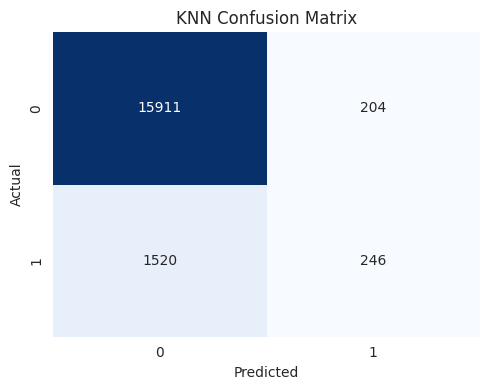


----- Random Forest -----
Accuracy : 0.9045
ROC-AUC  : 0.8737
PR-AUC   : 0.4349   (baseline = 0.0988)
F1 (pos) : 0.3297
Confusion Matrix:
 [[15753   362]
 [ 1346   420]]
              precision    recall  f1-score   support

           0      0.921     0.978     0.949     16115
           1      0.537     0.238     0.330      1766

    accuracy                          0.904     17881
   macro avg      0.729     0.608     0.639     17881
weighted avg      0.883     0.904     0.887     17881



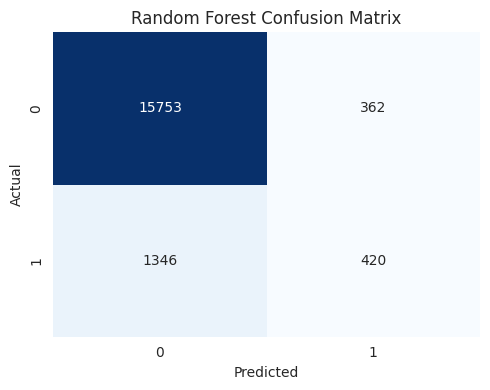


----- XGBoost -----
Accuracy : 0.8142
ROC-AUC  : 0.8786
PR-AUC   : 0.4664   (baseline = 0.0988)
F1 (pos) : 0.4468
Confusion Matrix:
 [[13216  2899]
 [  424  1342]]
              precision    recall  f1-score   support

           0      0.969     0.820     0.888     16115
           1      0.316     0.760     0.447      1766

    accuracy                          0.814     17881
   macro avg      0.643     0.790     0.668     17881
weighted avg      0.904     0.814     0.845     17881



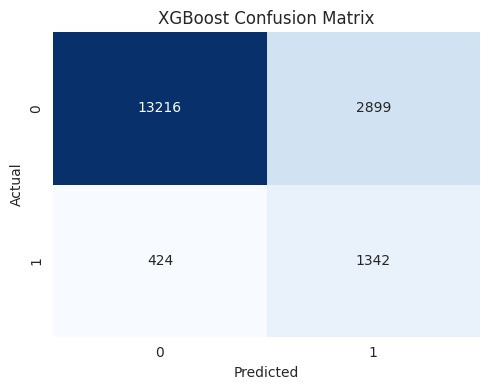


XGBoost 5-fold CV PR-AUC: 0.4775 (+/- 0.0059)


In [11]:
# ====================================================================
# 8. MODELS
# ====================================================================
print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# ---- 8.0 Baseline: Logistic Regression -----------------------------
logreg = LogisticRegression(max_iter=2000, class_weight="balanced",
                            random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
evaluate("Logistic Regression", logreg, X_test_s, y_test)

# ---- 8.1 K-Nearest Neighbours --------------------------------------
knn = KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1)
knn.fit(X_train_s, y_train)
evaluate("KNN", knn, X_test_s, y_test)
plot_confusion(y_test, knn.predict(X_test_s), "KNN Confusion Matrix")

# ---- 8.2 Random Forest ---------------------------------------------
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf, X_test, y_test)
plot_confusion(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")

# ---- 8.3 XGBoost ----------------------------------------------------
xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_lambda=1.0,
    scale_pos_weight=POS_WEIGHT,       # handles the 88/12 imbalance
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)
evaluate("XGBoost", xgb, X_test, y_test)
plot_confusion(y_test, xgb.predict(X_test), "XGBoost Confusion Matrix")

# ---- 8.4 Cross-validation on the best model -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv,
                            scoring="average_precision", n_jobs=-1)
print(f"\nXGBoost 5-fold CV PR-AUC: {cv_scores.mean():.4f} "
      f"(+/- {cv_scores.std():.4f})")



MODEL COMPARISON
                     accuracy  roc_auc  pr_auc      f1
Logistic Regression    0.7927   0.8427  0.3623  0.3969
KNN                    0.9036   0.7849  0.3363  0.2220
Random Forest          0.9045   0.8737  0.4349  0.3297
XGBoost                0.8142   0.8786  0.4664  0.4468


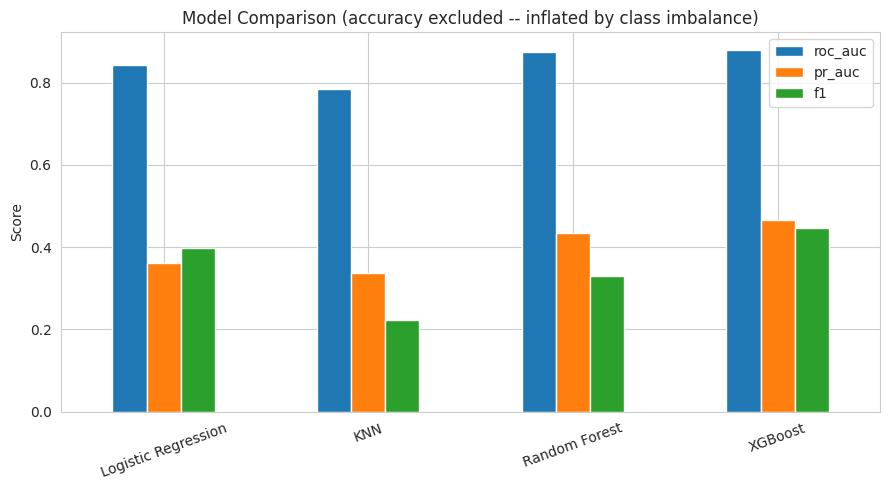

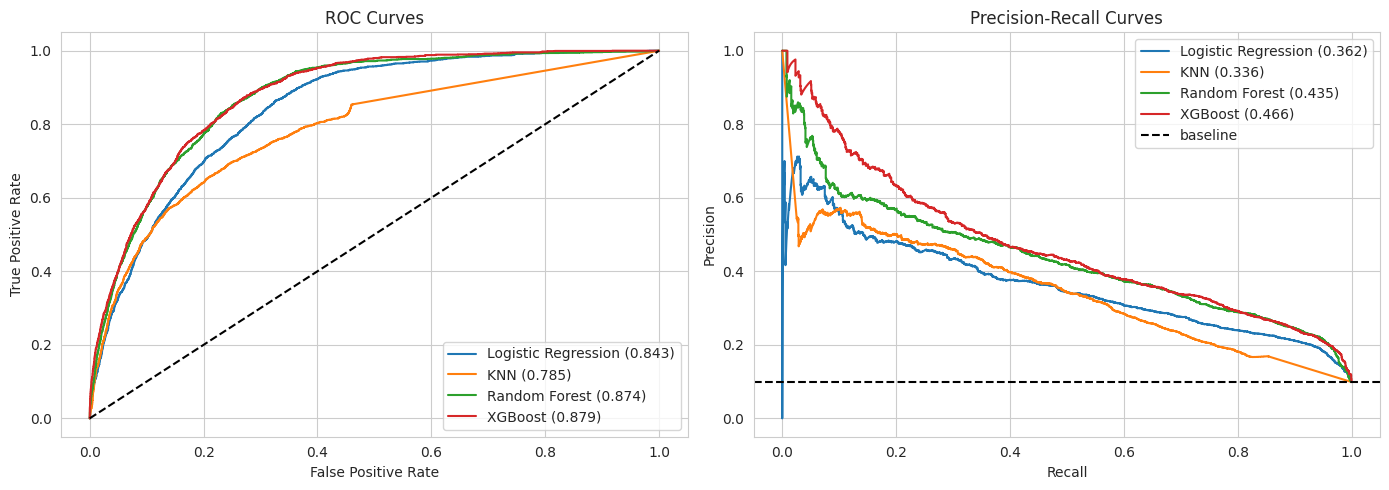

In [12]:
# ====================================================================
# 9. MODEL COMPARISON
# ====================================================================
comp = pd.DataFrame({k: {m: v[m] for m in ["accuracy", "roc_auc", "pr_auc", "f1"]}
                     for k, v in results.items()}).T.round(4)
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comp)

comp[["roc_auc", "pr_auc", "f1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison (accuracy excluded -- inflated by class imbalance)")
plt.ylabel("Score"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    axes[0].plot(fpr, tpr, label=f"{name} ({r['roc_auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    axes[1].plot(rec, prec, label=f"{name} ({r['pr_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend()
axes[1].axhline(y_test.mean(), color="k", ls="--", label="baseline")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend()
plt.tight_layout(); plt.show()



THRESHOLD TUNING (XGBoost)
Default threshold 0.50 -> F1 = 0.4468
Optimal threshold 0.63 -> F1 = 0.4658

Confusion matrix at optimal threshold:
[[14314  1801]
 [  683  1083]]


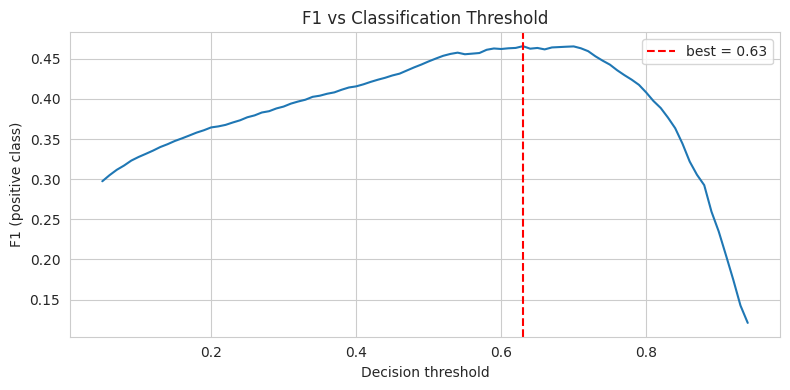

In [13]:
# ====================================================================
# 10. THRESHOLD TUNING
# ====================================================================
print("\n" + "=" * 60)
print("THRESHOLD TUNING (XGBoost)")
print("=" * 60)

proba = results["XGBoost"]["proba"]
thresholds = np.arange(0.05, 0.95, 0.01)
f1s = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]

print(f"Default threshold 0.50 -> F1 = {f1_score(y_test, (proba >= 0.5).astype(int)):.4f}")
print(f"Optimal threshold {best_t:.2f} -> F1 = {max(f1s):.4f}")
print("\nConfusion matrix at optimal threshold:")
print(confusion_matrix(y_test, (proba >= best_t).astype(int)))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1s)
plt.axvline(best_t, color="red", ls="--", label=f"best = {best_t:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("F1 (positive class)")
plt.title("F1 vs Classification Threshold")
plt.legend(); plt.tight_layout(); plt.show()

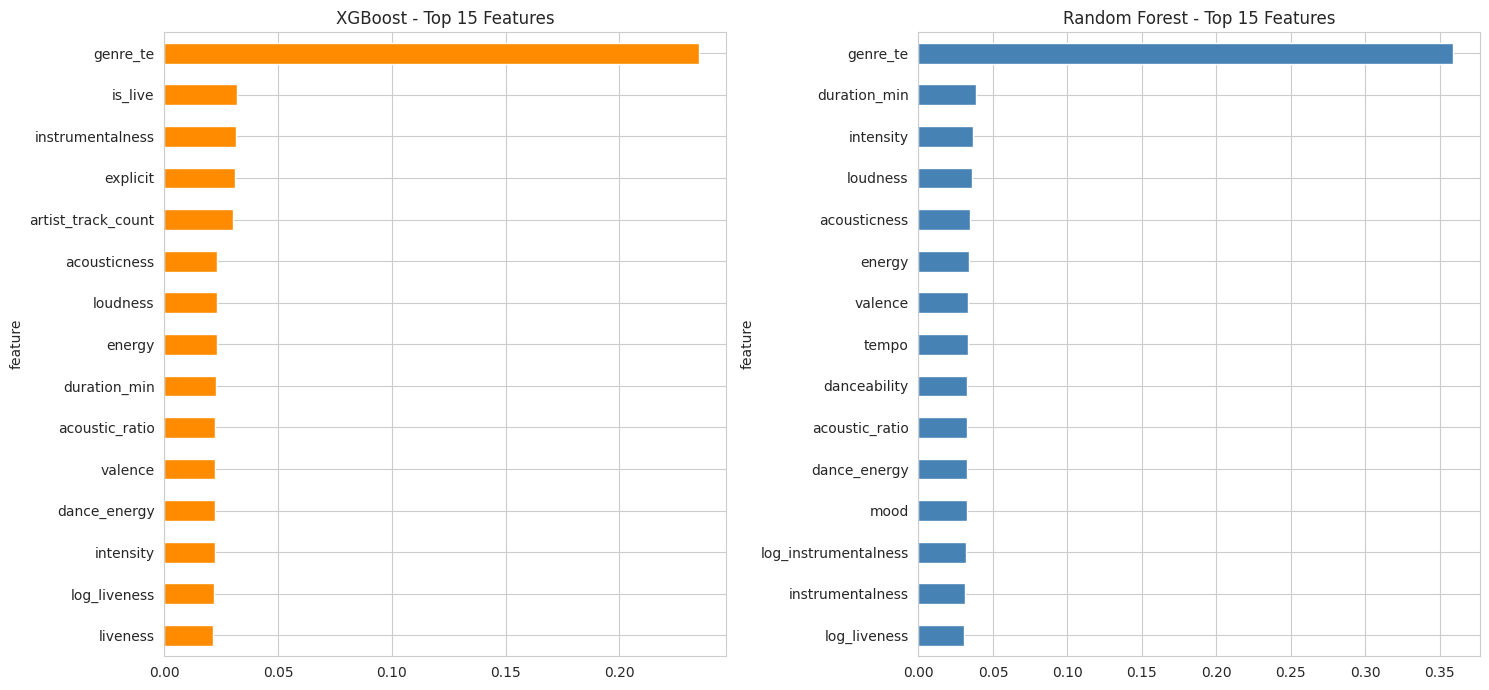


Top 10 features (XGBoost):
           feature       rf      xgb
          genre_te 0.359050 0.235079
           is_live 0.001992 0.031812
  instrumentalness 0.031113 0.031300
          explicit 0.004217 0.030818
artist_track_count 0.028883 0.030033
      acousticness 0.034513 0.023249
          loudness 0.035802 0.023188
            energy 0.033712 0.023095
      duration_min 0.038311 0.022809
    acoustic_ratio 0.032680 0.022447


In [14]:
# ====================================================================
# 11. FEATURE IMPORTANCE
# ====================================================================
imp = pd.DataFrame({
    "feature": FEATURES,
    "rf": rf.feature_importances_,
    "xgb": xgb.feature_importances_,
}).sort_values("xgb", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
imp.nlargest(15, "xgb").plot(x="feature", y="xgb", kind="barh",
                             ax=axes[0], legend=False, color="darkorange")
axes[0].set_title("XGBoost - Top 15 Features"); axes[0].invert_yaxis()
imp.nlargest(15, "rf").plot(x="feature", y="rf", kind="barh",
                            ax=axes[1], legend=False, color="steelblue")
axes[1].set_title("Random Forest - Top 15 Features"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

print("\nTop 10 features (XGBoost):")
print(imp.head(10).to_string(index=False))

# Optional: SHAP values for proper local + global interpretation
# import shap
# explainer = shap.TreeExplainer(xgb)
# shap_values = explainer.shap_values(X_test.sample(2000, random_state=RANDOM_STATE))
# shap.summary_plot(shap_values, X_test.sample(2000, random_state=RANDOM_STATE))


t-SNE


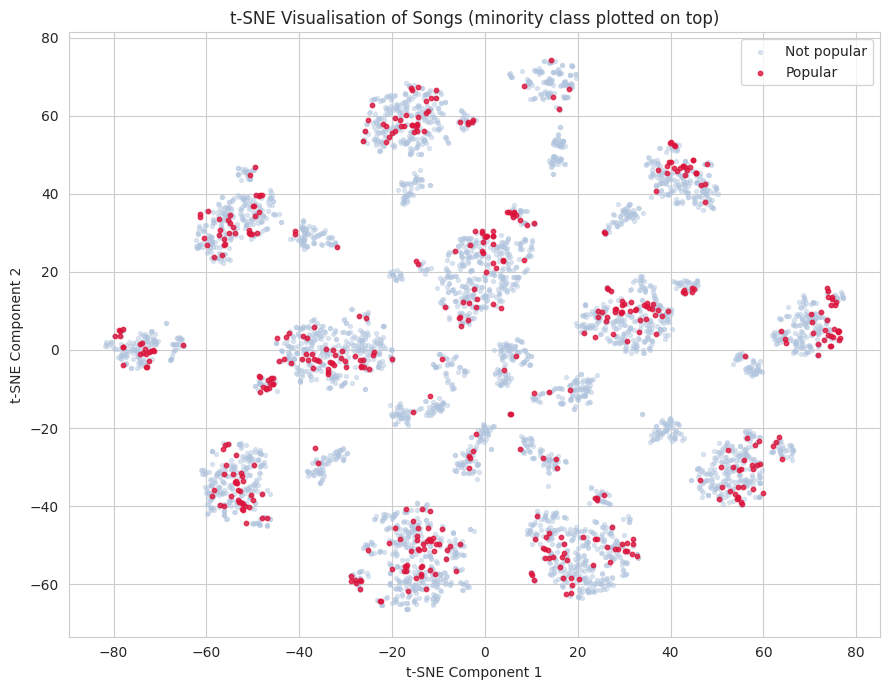


Done.


In [15]:
# ====================================================================
# 12. t-SNE VISUALISATION
# ====================================================================
print("\n" + "=" * 60)
print("t-SNE")
print("=" * 60)

SUB = 5000
idx = np.random.choice(len(X_train_s), SUB, replace=False)
X_sub, y_sub = X_train_s[idx], y_train.values[idx]

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
            init="pca", random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_sub)

plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[y_sub == 0, 0], X_tsne[y_sub == 0, 1],
            c="lightsteelblue", s=8, alpha=0.4, label="Not popular")
plt.scatter(X_tsne[y_sub == 1, 0], X_tsne[y_sub == 1, 1],
            c="crimson", s=10, alpha=0.8, label="Popular")
plt.xlabel("t-SNE Component 1"); plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualisation of Songs (minority class plotted on top)")
plt.legend(); plt.tight_layout(); plt.show()

print("\nDone.")


Logistic Regression
          Pred 0  Pred 1
Actual 0   12954    3161
Actual 1     546    1220
              precision    recall  f1-score   support

 Not popular      0.960     0.804     0.875     16115
     Popular      0.278     0.691     0.397      1766

    accuracy                          0.793     17881
   macro avg      0.619     0.747     0.636     17881
weighted avg      0.892     0.793     0.828     17881

KNN
          Pred 0  Pred 1
Actual 0   15911     204
Actual 1    1520     246
              precision    recall  f1-score   support

 Not popular      0.913     0.987     0.949     16115
     Popular      0.547     0.139     0.222      1766

    accuracy                          0.904     17881
   macro avg      0.730     0.563     0.585     17881
weighted avg      0.877     0.904     0.877     17881

Random Forest
          Pred 0  Pred 1
Actual 0   15753     362
Actual 1    1346     420
              precision    recall  f1-score   support

 Not popular      0.921     

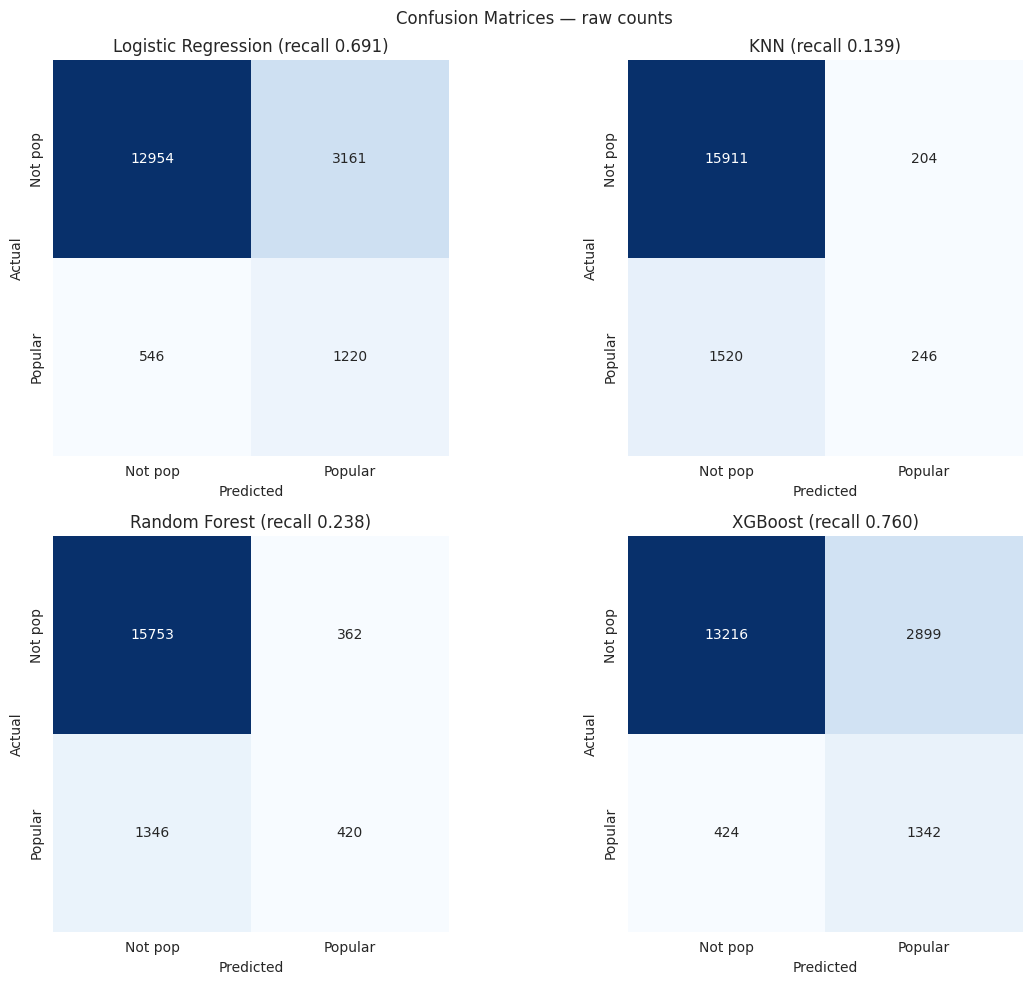

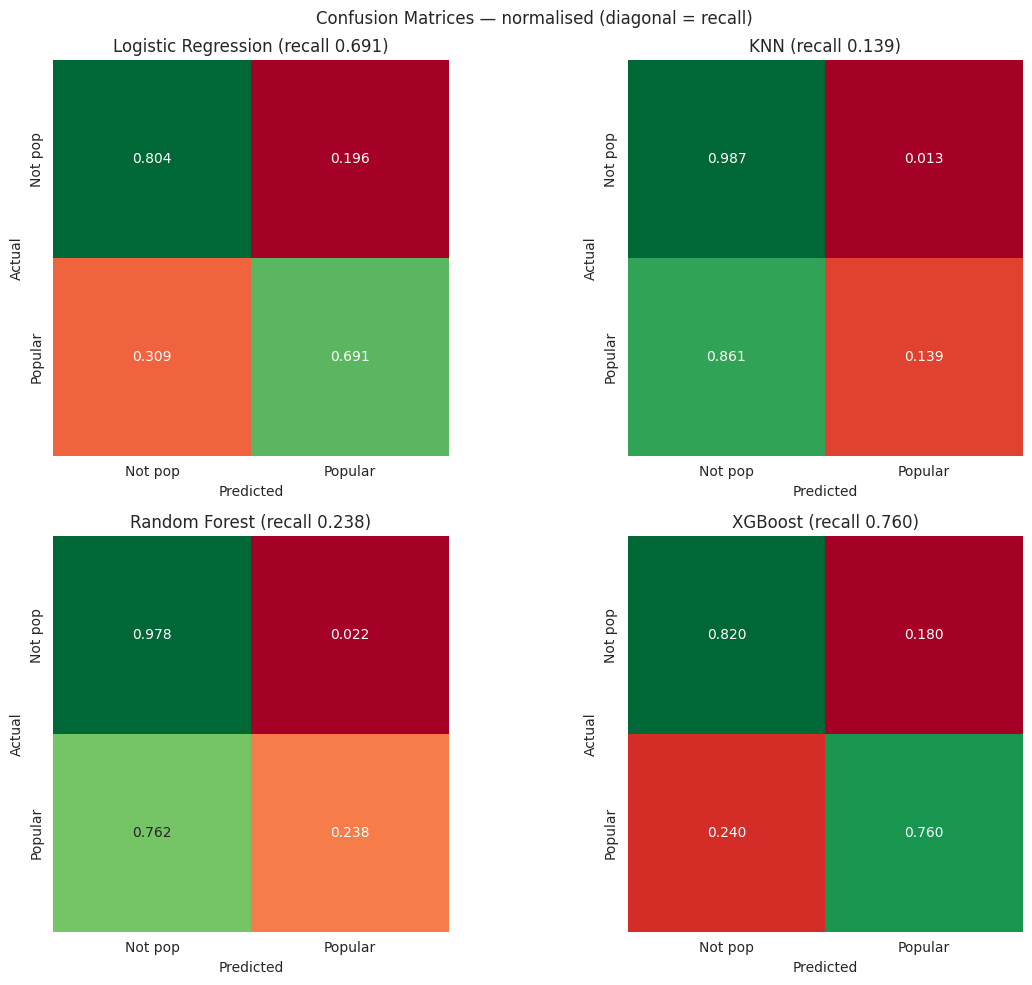

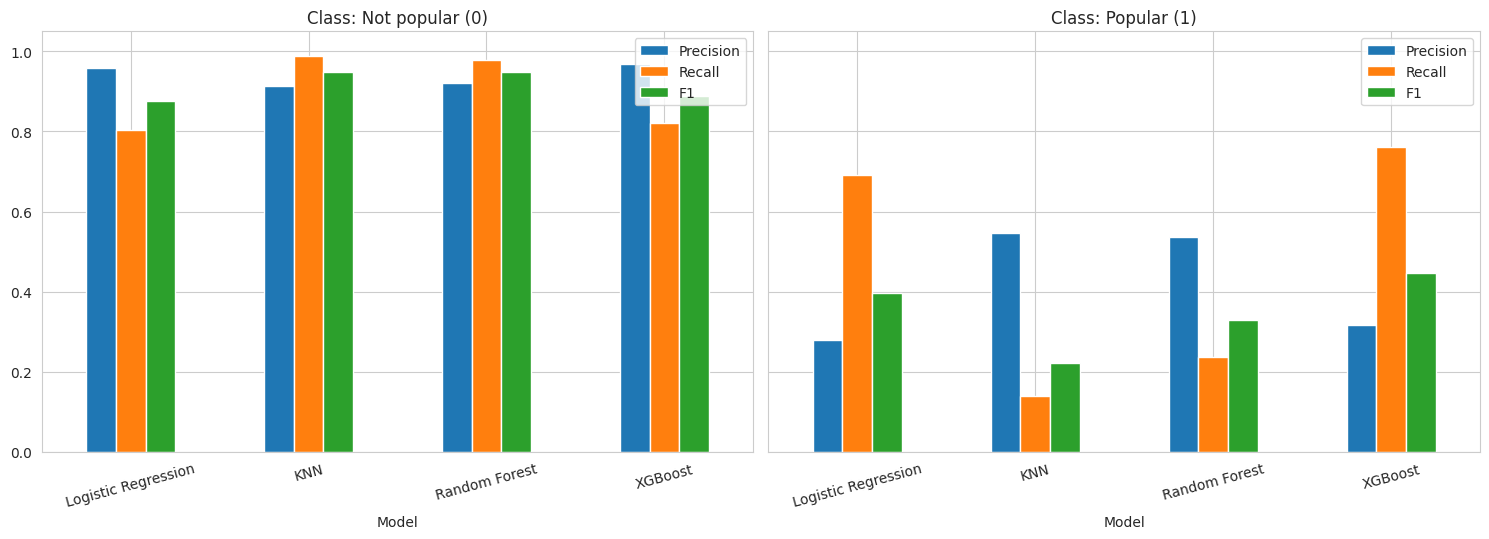

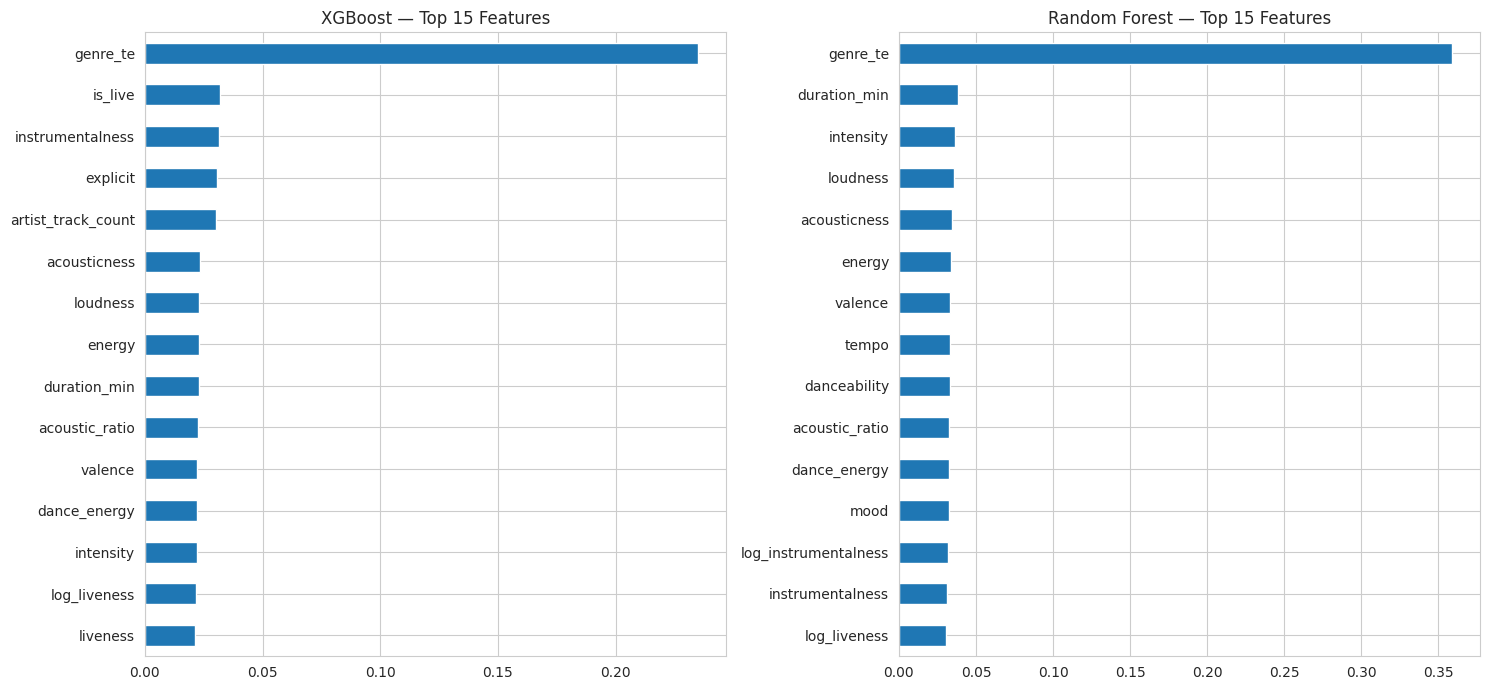

| Model               |   Accuracy |   Balanced Acc |   ROC-AUC |   PR-AUC |   F1 (popular) |    MCC |
|:--------------------|-----------:|---------------:|----------:|---------:|---------------:|-------:|
| Logistic Regression |     0.7927 |         0.7473 |    0.8427 |   0.3623 |         0.3969 | 0.3431 |
| KNN                 |     0.9036 |         0.5633 |    0.7849 |   0.3363 |         0.222  | 0.2412 |
| Random Forest       |     0.9045 |         0.6077 |    0.8737 |   0.4349 |         0.3297 | 0.3142 |
| XGBoost             |     0.8142 |         0.79   |    0.8786 |   0.4664 |         0.4468 | 0.4068 |

 | Model               | Class           |   Precision |   Recall |     F1 |   Support |
|:--------------------|:----------------|------------:|---------:|-------:|----------:|
| Logistic Regression | Not popular (0) |      0.9596 |   0.8038 | 0.8748 |     16115 |
| Logistic Regression | Popular (1)     |      0.2785 |   0.6908 | 0.3969 |      1766 |
| KNN                 | Not 

In [16]:
# ===== EXTRA CELL: CM + Heatmap + Precision/Recall/F1 + FI + Comparison =====
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_fscore_support, accuracy_score,
                             balanced_accuracy_score, roc_auc_score,
                             average_precision_score, matthews_corrcoef, f1_score)

MODELS = {"Logistic Regression": (logreg, X_test_s),
          "KNN":                 (knn,    X_test_s),
          "Random Forest":       (rf,     X_test),
          "XGBoost":             (xgb,    X_test)}

overall, per_class, store = [], [], {}

for name, (m, Xte) in MODELS.items():
    pred  = m.predict(Xte)
    proba = m.predict_proba(Xte)[:, 1]
    cm = confusion_matrix(y_test, pred)
    store[name] = (cm, pred, proba)

    print("="*60); print(name); print("="*60)
    print(pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Pred 0","Pred 1"]))
    print(classification_report(y_test, pred, digits=3,
                                target_names=["Not popular","Popular"]))

    overall.append({"Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Acc": balanced_accuracy_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "F1 (popular)": f1_score(y_test, pred),
        "MCC": matthews_corrcoef(y_test, pred)})

    p, r, f, s = precision_recall_fscore_support(y_test, pred, labels=[0,1])
    for i, c in enumerate(["Not popular (0)","Popular (1)"]):
        per_class.append({"Model": name, "Class": c,
                          "Precision": p[i], "Recall": r[i], "F1": f[i], "Support": s[i]})

res = pd.DataFrame(overall); pcm = pd.DataFrame(per_class)

# ---- CM heatmaps (raw + normalised) ----
for norm in [False, True]:
    fig, axes = plt.subplots(2, 2, figsize=(12,10))
    for ax, (name,(cm,pred,_)) in zip(axes.ravel(), store.items()):
        M = cm/cm.sum(axis=1, keepdims=True) if norm else cm
        sns.heatmap(M, annot=True, fmt=".3f" if norm else "d",
                    cmap="RdYlGn" if norm else "Blues", cbar=False, square=True, ax=ax,
                    xticklabels=["Not pop","Popular"], yticklabels=["Not pop","Popular"])
        ax.set_title(f"{name} (recall {cm[1,1]/cm[1].sum():.3f})")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.suptitle("Confusion Matrices — " + ("normalised (diagonal = recall)" if norm else "raw counts"))
    plt.tight_layout(); plt.show()

# ---- Per-class precision/recall/F1 ----
fig, axes = plt.subplots(1, 2, figsize=(15,5.5), sharey=True)
for ax, c in zip(axes, ["Not popular (0)","Popular (1)"]):
    pcm[pcm.Class==c].set_index("Model")[["Precision","Recall","F1"]].plot(kind="bar", ax=ax, rot=15)
    ax.set_title(f"Class: {c}"); ax.set_ylim(0,1.05)
plt.tight_layout(); plt.show()

# ---- Feature importance ----
fig, axes = plt.subplots(1, 2, figsize=(15,7))
for ax, (mdl, ttl) in zip(axes, [(xgb,"XGBoost"), (rf,"Random Forest")]):
    (pd.Series(mdl.feature_importances_, index=FEATURES)
       .nlargest(15).sort_values().plot(kind="barh", ax=ax))
    ax.set_title(f"{ttl} — Top 15 Features")
plt.tight_layout(); plt.show()

# ---- Comparison table + conclusion ----
base_pr, base_acc = y_test.mean(), 1-y_test.mean()
print(res.round(4).to_markdown(index=False))
print("\n", pcm.round(4).to_markdown(index=False))

rk = res.sort_values("PR-AUC", ascending=False).reset_index(drop=True)
print(f"\nBEST MODEL: {rk.loc[0,'Model']}  (PR-AUC {rk.loc[0,'PR-AUC']:.4f}, "
      f"baseline {base_pr:.4f}, lift {rk.loc[0,'PR-AUC']/base_pr:.2f}x)")
print(f"Runner-up: {rk.loc[1,'Model']} ({rk.loc[1,'PR-AUC']:.4f}), margin {rk.loc[0,'PR-AUC']-rk.loc[1,'PR-AUC']:.4f}")
print(f"Highest accuracy: {res.loc[res.Accuracy.idxmax(),'Model']} ({res.Accuracy.max():.4f}) "
      f"— but majority baseline is already {base_acc:.4f}, so accuracy is not the ranking metric.")
for i, r_ in rk.iterrows():
    print(f"  {i+1}. {r_['Model']:<22} PR-AUC {r_['PR-AUC']:.4f}  F1 {r_['F1 (popular)']:.4f}  MCC {r_['MCC']:.4f}")

In [17]:
# ===== EXTRA CELL: winner table =====
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             average_precision_score, f1_score, matthews_corrcoef,
                             precision_score, recall_score)

MODELS = {"Logistic Regression": (logreg, X_test_s),
          "KNN":                 (knn,    X_test_s),
          "Random Forest":       (rf,     X_test),
          "XGBoost":             (xgb,    X_test)}

rows = []
for name, (m, Xte) in MODELS.items():
    pred, proba = m.predict(Xte), m.predict_proba(Xte)[:, 1]
    rows.append({"Model": name,
                 "Accuracy":     accuracy_score(y_test, pred),
                 "Balanced Acc": balanced_accuracy_score(y_test, pred),
                 "Precision (1)": precision_score(y_test, pred, zero_division=0),
                 "Recall (1)":    recall_score(y_test, pred),
                 "F1 (1)":        f1_score(y_test, pred),
                 "ROC-AUC":       roc_auc_score(y_test, proba),
                 "PR-AUC":        average_precision_score(y_test, proba),
                 "MCC":           matthews_corrcoef(y_test, pred)})

cmp = pd.DataFrame(rows).set_index("Model")
base_acc, base_pr = 1 - y_test.mean(), y_test.mean()

# rank each metric (1 = best) and average the ranks
ranks = cmp.rank(ascending=False)
cmp["Avg rank"] = ranks.mean(axis=1)
cmp = cmp.sort_values("PR-AUC", ascending=False)

print(f"Majority-class baseline accuracy : {base_acc:.4f}")
print(f"Random baseline PR-AUC           : {base_pr:.4f}\n")
print(cmp.round(4).to_markdown())

# highlight the winner per metric
print("\nBest model per metric:")
for c in cmp.columns.drop("Avg rank"):
    print(f"  {c:<15} {cmp[c].idxmax():<22} {cmp[c].max():.4f}")

win_pr  = cmp["PR-AUC"].idxmax()
win_acc = cmp["Accuracy"].idxmax()
print(f"\n>>> WINNER (PR-AUC, primary metric): {win_pr}")
print(f">>> Highest raw accuracy           : {win_acc} ({cmp['Accuracy'].max():.4f})")
if cmp["Accuracy"].max() <= base_acc + 0.005:
    print("    NOTE: that accuracy is at or below the majority-class baseline —")
    print("    it is not evidence of a good model.")
if win_acc != win_pr:
    print(f"    Accuracy and PR-AUC disagree. PR-AUC decides, because accuracy on a")
    print(f"    {base_pr:.1%} positive class rewards predicting the majority class.")

cmp.round(4).to_csv("model_winner_table.csv")

Majority-class baseline accuracy : 0.9012
Random baseline PR-AUC           : 0.0988

| Model               |   Accuracy |   Balanced Acc |   Precision (1) |   Recall (1) |   F1 (1) |   ROC-AUC |   PR-AUC |    MCC |   Avg rank |
|:--------------------|-----------:|---------------:|----------------:|-------------:|---------:|----------:|---------:|-------:|-----------:|
| XGBoost             |     0.8142 |         0.79   |          0.3164 |       0.7599 |   0.4468 |    0.8786 |   0.4664 | 0.4068 |      1.5   |
| Random Forest       |     0.9045 |         0.6077 |          0.5371 |       0.2378 |   0.3297 |    0.8737 |   0.4349 | 0.3142 |      2.375 |
| Logistic Regression |     0.7927 |         0.7473 |          0.2785 |       0.6908 |   0.3969 |    0.8427 |   0.3623 | 0.3431 |      2.75  |
| KNN                 |     0.9036 |         0.5633 |          0.5467 |       0.1393 |   0.222  |    0.7849 |   0.3363 | 0.2412 |      3.375 |

Best model per metric:
  Accuracy        Random Forest  

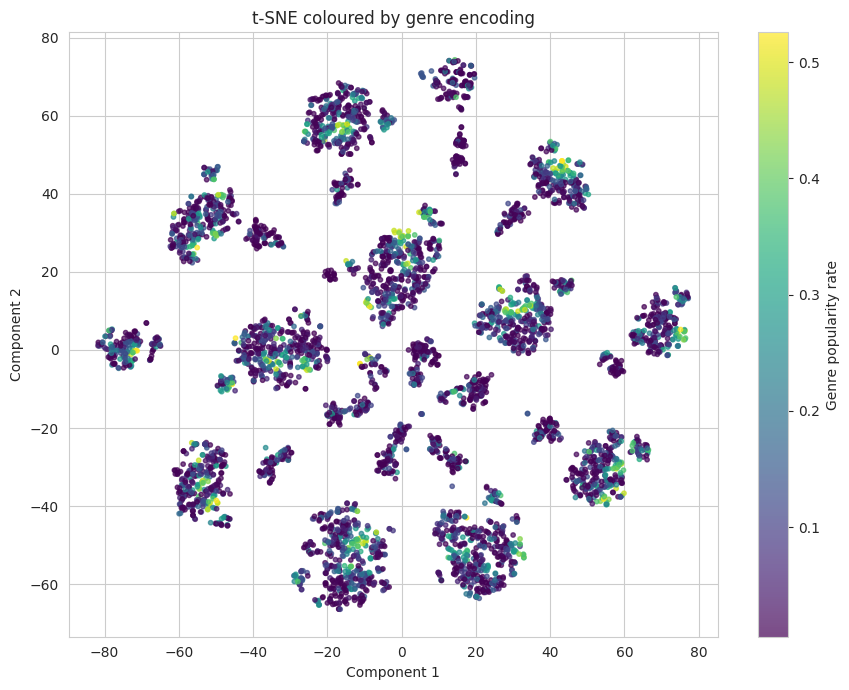

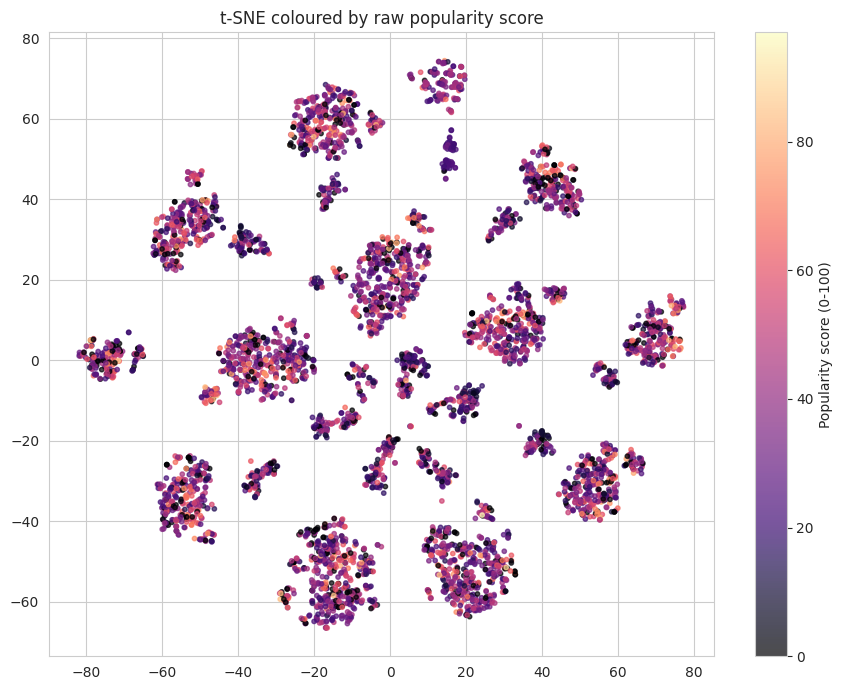

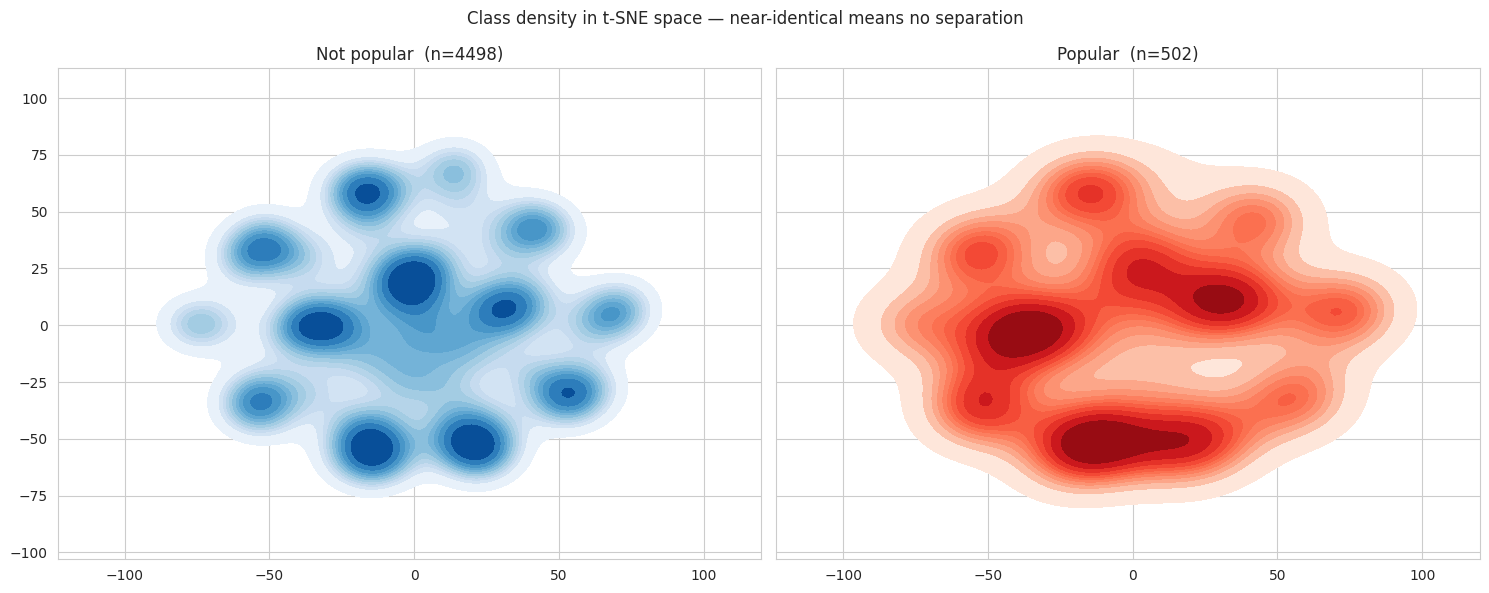

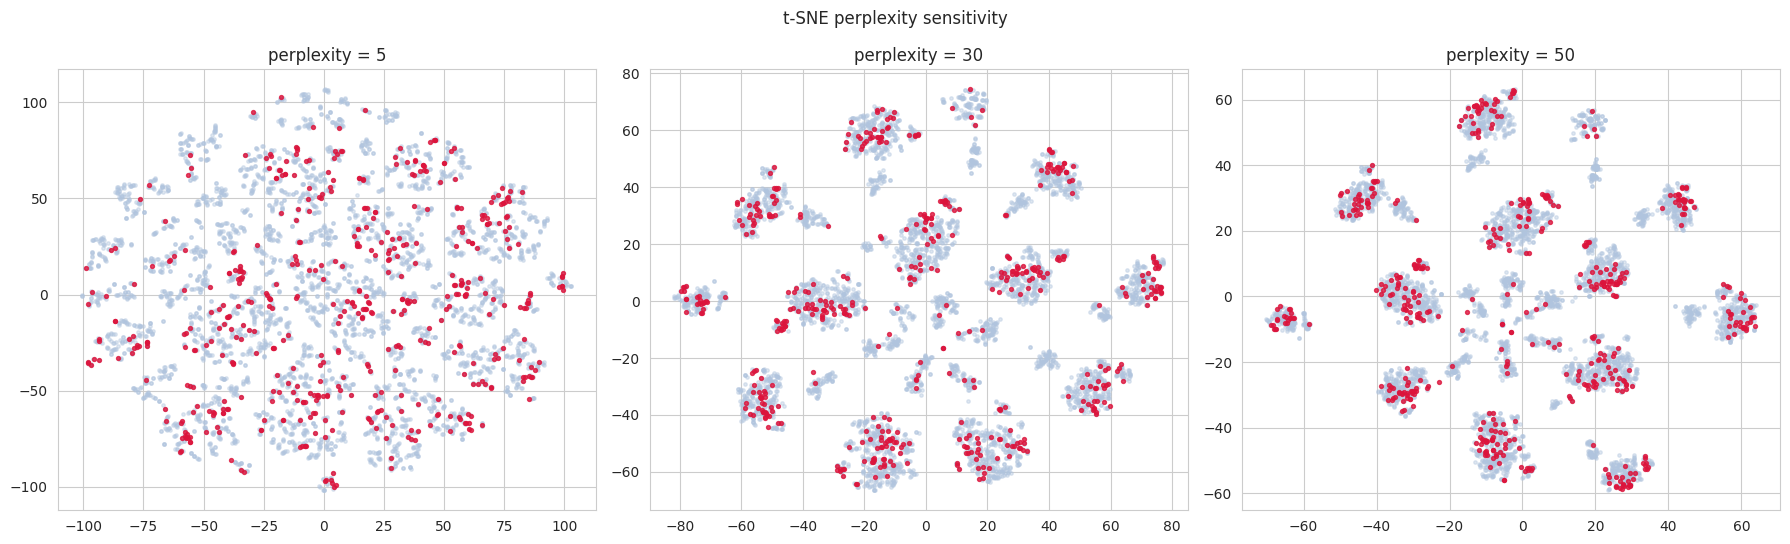

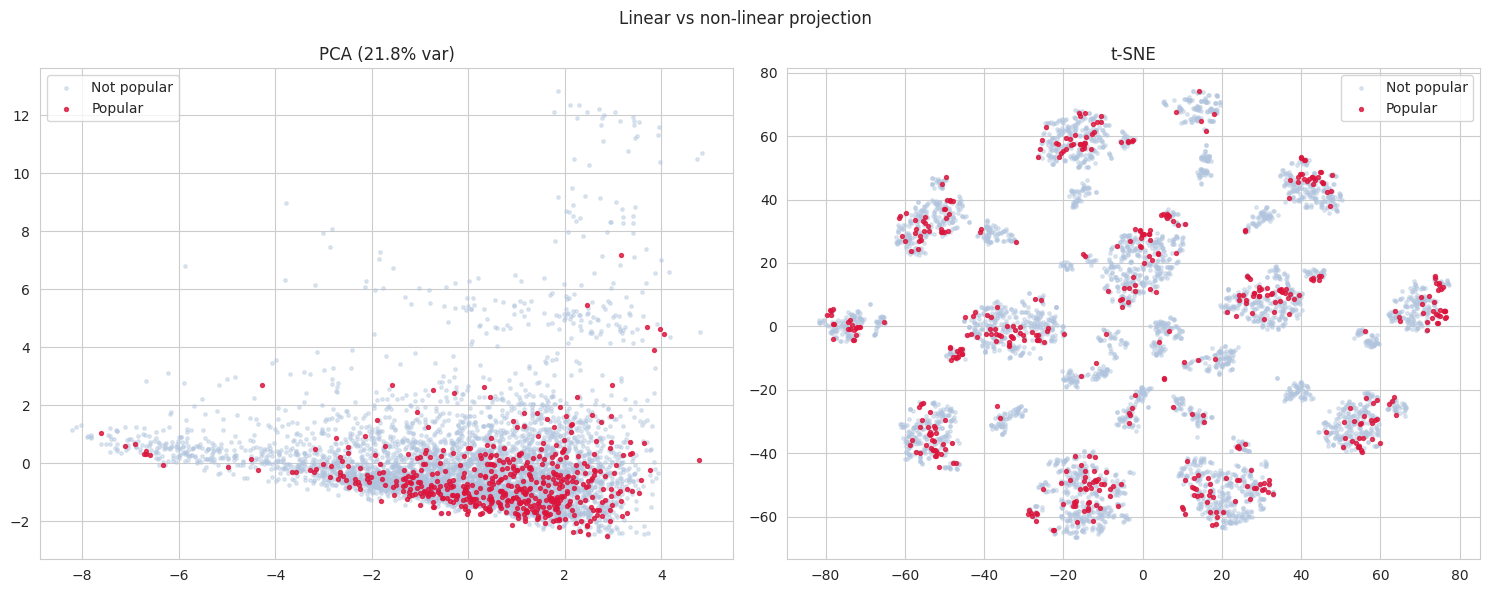

In [18]:
# ===== EXTRA CELL: additional t-SNE views =====
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sub_df = fe.iloc[X_train.index[idx]]        # rows matching the t-SNE subsample

# --- 1. Coloured by genre popularity rate (the variable with real signal) ---
plt.figure(figsize=(9, 7))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sub_df["genre_te"].values
                 if "genre_te" in sub_df else X_train.iloc[idx]["genre_te"].values,
                 cmap="viridis", s=10, alpha=0.7)
plt.colorbar(sc, label="Genre popularity rate")
plt.title("t-SNE coloured by genre encoding")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.tight_layout(); plt.show()

# --- 2. Coloured by continuous popularity score, not the binary label ---
plt.figure(figsize=(9, 7))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sub_df["popularity"].values,
                 cmap="magma", s=10, alpha=0.7)
plt.colorbar(sc, label="Popularity score (0-100)")
plt.title("t-SNE coloured by raw popularity score")
plt.tight_layout(); plt.show()

# --- 3. Density comparison: where each class actually sits ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for ax, (cls, lbl, cmap) in zip(axes, [(0, "Not popular", "Blues"),
                                       (1, "Popular", "Reds")]):
    m = y_sub == cls
    sns.kdeplot(x=X_tsne[m, 0], y=X_tsne[m, 1], fill=True,
                cmap=cmap, levels=12, thresh=0.05, ax=ax)
    ax.set_title(f"{lbl}  (n={m.sum()})")
plt.suptitle("Class density in t-SNE space — near-identical means no separation")
plt.tight_layout(); plt.show()

# --- 4. Perplexity sensitivity: shows the embedding is not an artefact ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, perp in zip(axes, [5, 30, 50]):
    emb = TSNE(n_components=2, perplexity=perp, init="pca",
               learning_rate="auto", random_state=42).fit_transform(X_sub)
    ax.scatter(emb[y_sub == 0, 0], emb[y_sub == 0, 1],
               c="lightsteelblue", s=6, alpha=0.4)
    ax.scatter(emb[y_sub == 1, 0], emb[y_sub == 1, 1],
               c="crimson", s=8, alpha=0.8)
    ax.set_title(f"perplexity = {perp}")
plt.suptitle("t-SNE perplexity sensitivity")
plt.tight_layout(); plt.show()

# --- 5. PCA side by side: linear vs non-linear, same conclusion ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sub)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (emb, ttl) in zip(axes, [(X_pca, f"PCA ({pca.explained_variance_ratio_.sum():.1%} var)"),
                                 (X_tsne, "t-SNE")]):
    ax.scatter(emb[y_sub == 0, 0], emb[y_sub == 0, 1],
               c="lightsteelblue", s=6, alpha=0.4, label="Not popular")
    ax.scatter(emb[y_sub == 1, 0], emb[y_sub == 1, 1],
               c="crimson", s=8, alpha=0.8, label="Popular")
    ax.set_title(ttl); ax.legend()
plt.suptitle("Linear vs non-linear projection")
plt.tight_layout(); plt.show()